This notebook is to analyze the residuals.
Sum of Squares Due to Error.   This statistic measures the total deviation of the response values from the fit to the response values.
It is also called the summed square of residuals and is usually labeled as SSE.

In [3]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import csv

In [4]:
base_path = Path('C:\\Users\\thinkBookUser\\Desktop\\Screening_Data_Analyzed')
fit = Path(base_path,'2019','11','07','chemical','results','D3_fit.csv')
fit = all_data1 = pd.read_csv(fit)
tau = Path(base_path,'2019','11','07','chemical','results','D3_tau.csv')
tau = all_data1 = pd.read_csv(tau,'\t',header=None)

In [5]:
tau.head()

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
0,2.220445,2.243348,2.240552,2.326280,2.158671,2.273617,2.258518,2.244526,2.253770,2.269362,...,3.081301,3.166175,3.075127,3.143193,3.125563,3.142544,3.156363,3.110541,3.162862,3.115879
1,2.254891,2.283476,2.323302,2.273868,2.331584,2.276048,2.326549,2.345896,2.414014,2.714481,...,3.179124,3.174623,3.194207,3.198114,3.208579,3.227058,3.204608,3.218553,3.231330,3.229343
2,2.281141,2.217342,2.297259,2.184405,2.192184,2.232253,2.254042,2.270968,2.220795,2.287202,...,3.116903,3.109153,3.122060,3.125493,3.126325,3.158738,3.153035,3.141782,3.139618,3.128236
3,2.314024,2.294198,2.310177,2.310385,2.323516,2.307928,2.303915,2.299827,2.281462,2.371419,...,3.158475,3.187946,3.169991,3.179181,3.185410,3.198122,3.183070,3.188008,3.171575,3.174624
4,2.263252,2.251100,2.236672,2.247942,2.244185,2.192811,2.217163,2.243330,2.255075,2.349401,...,3.121253,3.108956,3.165239,3.177293,3.164655,3.175481,3.149709,3.171670,3.121595,3.166541


In [6]:
fit.head()

,Unnamed: 0,start(ns),range(ns),breakdown_time(s),midpoint(s),start tau(ns),e_start,e_range,e_breakdown_time,e_midpoint,error,condition
0,0,3.505402,-1.271021,250.546459,200.000000,2.242213,0.163631,0.212031,55.421382,15.097601,16.0,PDE3A
1,1,3.298148,-0.920308,100.420019,200.000000,2.303057,0.026015,0.031396,9.015632,2.582711,0.0,PDE3A
2,2,3.123814,-0.847791,134.863346,200.000000,2.222798,0.030563,0.037102,12.073459,3.490136,0.0,PDE3A
3,3,2.986451,-0.657592,42.139706,132.378089,2.309569,0.021848,0.022509,3.289063,1.140023,0.0,PDE3A
4,4,3.125982,-0.847974,49.516680,135.126679,2.244975,0.026207,0.027036,3.297159,1.187613,0.0,PDE3A


In [7]:
fit_sel = fit[fit['breakdown_time(s)'] > 150]
fit_sel = fit_sel[fit_sel['error']==0]
fit_sel.head()

,Unnamed: 0,start(ns),range(ns),breakdown_time(s),midpoint(s),start tau(ns),e_start,e_range,e_breakdown_time,e_midpoint,error,condition
362,362,3.17789,-0.82906,189.390669,200.0,2.346746,0.04512,0.056236,20.147381,5.790926,0.0,PDE3A


In [8]:
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c)) 

In [9]:
curve_nr = 362
fit_vals= fit.loc[curve_nr,:]
fit_vals

Unnamed: 0                 362
start(ns)              3.17789
range(ns)             -0.82906
breakdown_time(s)      189.391
midpoint(s)                200
start tau(ns)          2.34675
e_start              0.0451195
e_range              0.0562356
e_breakdown_time       20.1474
e_midpoint             5.79093
error                        0
condition                PDE3A
Name: 362, dtype: object

In [10]:
frametime = 5
x = np.arange(0,frametime*len(tau.columns),frametime)
print(x)
print('n_x =', len(x))

[  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175
 180 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265
 270 275 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355
 360 365 370 375 380 385 390 395 400 405 410 415 420 425 430 435 440 445
 450 455 460 465 470 475 480 485 490 495 500 505 510 515]
n_x = 104


In [11]:
y = (tau.loc[curve_nr,:])
print(y)
print('n_y =', len(y))

0      2.344847
1      2.331702
2      2.346136
3      2.337460
4      2.371688
         ...   
99     3.180171
100    3.167215
101    3.181801
102    3.190215
103    3.198929
Name: 362, Length: 104, dtype: float64
n_y = 104


In [12]:
yfit = fit_function(x,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown_time(s)'],fit_vals['midpoint(s)'])
print(yfit)
print('n_yfit =', len(yfit))

[3.16592846 3.16461753 3.16316552 3.16155784 3.15977853 3.15781016
 3.15563373 3.15322859 3.15057234 3.14764075 3.14440769 3.1408451
 3.13692296 3.1326093  3.12787026 3.12267018 3.11697177 3.11073634
 3.10392413 3.09649469 3.08840744 3.07962227 3.07010029 3.05980475
 3.04870196 3.03676245 3.0239622  3.01028382 2.99571792 2.98026438
 2.96393349 2.9467471  2.92873938 2.90995739 2.8904613  2.87032415
 2.84963124 2.82847891 2.80697309 2.78522722 2.76335998 2.74149274
 2.71974686 2.69824104 2.67708872 2.6563958  2.63625866 2.61676257
 2.59798057 2.57997285 2.56278646 2.54645558 2.53100203 2.51643614
 2.50275775 2.4899575  2.478018   2.46691521 2.45661966 2.44709769
 2.43831252 2.43022527 2.42279583 2.41598361 2.40974818 2.40404977
 2.39884969 2.39411065 2.38979699 2.38587486 2.38231227 2.37907921
 2.37614761 2.37349136 2.37108622 2.3689098  2.36694143 2.36516211
 2.36355443 2.36210242 2.3607915  2.35960834 2.35854083 2.35757791
 2.35670956 2.35592666 2.35522094 2.35458491 2.35401178 2.35349

In [13]:
y_sigma = np.random.random(len(y)) 
print(y_sigma)
print('n_ysigma =', len(y_sigma))

[0.79859659 0.92947084 0.14737783 0.77950245 0.08295475 0.968346
 0.9696556  0.21869053 0.71679266 0.57656038 0.87842025 0.54411175
 0.53099051 0.70118707 0.36264961 0.53040469 0.35677931 0.5703712
 0.28415048 0.01789444 0.04239873 0.16053843 0.38650948 0.10026489
 0.76005254 0.31106707 0.45162864 0.00304752 0.24903722 0.85063657
 0.51087845 0.06919608 0.22731572 0.58299583 0.02058904 0.9780002
 0.69427543 0.82743724 0.67904969 0.57571792 0.72096412 0.40969781
 0.80779996 0.33020267 0.0225802  0.71596626 0.80330494 0.15386706
 0.86227022 0.99658874 0.49926718 0.2983361  0.70601416 0.68868888
 0.33195793 0.92990398 0.8686637  0.29474167 0.76879497 0.2161056
 0.89267542 0.09860727 0.30820029 0.45241773 0.04052244 0.26338187
 0.47654216 0.54883186 0.45170115 0.57991465 0.97978519 0.61951062
 0.83499119 0.59588866 0.43222574 0.35832857 0.97645406 0.99725395
 0.23150369 0.75308932 0.096575   0.69928514 0.67729202 0.21209718
 0.03489097 0.75834556 0.6333806  0.02190583 0.52989504 0.85549598


In [14]:
#here are the start and end values that mark the span where we compare y and yfit values
start=20
end=60

Unnamed: 0                 362
start(ns)              3.17789
range(ns)             -0.82906
breakdown_time(s)      189.391
midpoint(s)                200
start tau(ns)          2.34675
e_start              0.0451195
e_range              0.0562356
e_breakdown_time       20.1474
e_midpoint             5.79093
error                        0
condition                PDE3A
Name: 362, dtype: object

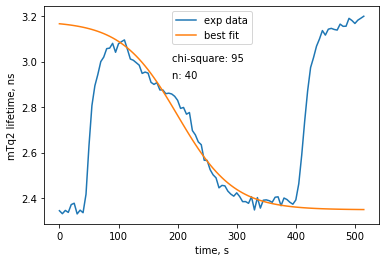

In [15]:
plt.xlabel("time, s")
plt.ylabel("mTq2 lifetime, ns")
plt.plot(x,y, label="exp data")
plt.plot(x,yfit, label="best fit")
plt.legend()
chisq = sum(((y[start:end]-yfit[start:end])/y_sigma[start:end])**2)
plt.figtext(0.42, 0.69, "chi-square: %.0f"%chisq)
n = len(y[start:end])
plt.figtext(0.42, 0.63, "n: %.0f"%n)
fit_vals

In [16]:
yresid = y - yfit
print(yresid)

0     -0.821081
1     -0.832916
2     -0.817029
3     -0.824098
4     -0.788090
         ...   
99     0.829712
100    0.816920
101    0.831652
102    0.840198
103    0.849031
Name: 362, Length: 104, dtype: float64


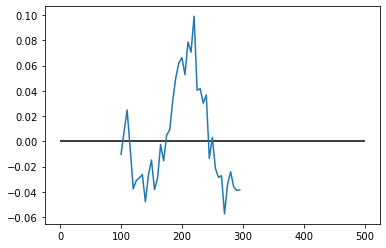

In [17]:
#here I tried to just plot the residuals between the xperimental values and the fitted values
plt.plot(x[start:end], yresid[start:end])
#plt.plot(x, yresid)
plt.hlines(0, 0, 500)

In [ ]:
#  The residual sum of squares is used to help you decide if a statistical model is a good fit for your data. 
SSresid = sum(yresid[start:end]**2)
# The Total SS (TSS or SST) tells you how much variation there is in the dependent variable. SStotal = Σ((Yi – mean of Y)**2).
# or also people use: SStotal = n*var(Y)
SStotal = len(y[start:end]) * np.var(y)
Rsq = 1-(SSresid/SStotal)
print("SSresid = %.2f"%SSresid)
print("SStotal = %.2f"%SStotal)
print("Rsq = %.2f"%Rsq)
# this formula works in the more linear area of our curve, BUT
# but Kees pointed out, that we must use the variance in data aqusition, not of actual y values like is here in the formul

In [ ]:
#The root-mean-square deviation (RMSD): sqrt(SSresid/n)

RMSD = np.sqrt(SSresid / len(y[start:end]))
print(RMSD)

In [18]:
#  Here I try to use our simulated std of y-values, but up there np.var(y) results in a single number, here y_sigma is an array, does not work directly
# And if I take the np.var(y_sigma) then I am again back to totally simulating the Rsq
SSresid = sum(yresid[start:end]**2)
SStotal = len(y[start:end]) * np.var(y_sigma[start:end])
Rsq = 1-(SSresid/SStotal)
print("SSresid = %.2f"%SSresid)
print("SStotal = %.2f"%SStotal)
print("Rsq = %.2f"%Rsq)

SSresid = 0.06
SStotal = 3.74
Rsq = 0.98


In [21]:
#The root-mean-square deviation (RMSD): sqrt(SSresid/n)

RMSD = np.sqrt(SSresid / len(y[start:end]))
print(RMSD)

0.03979002928796322


In [38]:
#  Here I try to use our simulated std of y-values, but up there np.var(y) results in a single number, here y_sigma is an array, does not work directly
# And if I take the np.var(y_sigma) then I am again back to totally simulating the Rsq
SSresid = sum(yresid[start:end]**2)
SStotal = len(y[start:end]) * np.var(y_sigma[start:end])
Rsq = 1-(SSresid/SStotal)
print("SSresid = %.2f"%SSresid)
print("SStotal = %.2f"%SStotal)
print("Rsq = %.2f"%Rsq)

SSresid = 0.06
SStotal = 4.10
Rsq = 0.98


In [35]:
#If this were a case for linear regression
from scipy.stats import *
# for demo I will take the steepest part of our curve
start_lin=25
stop_lin=45
slope, intercept, r_value, p_value, std_err = linregress(x[start_lin:stop_lin],y[start_lin:stop_lin])
print("Rsq = %.2f"%r_value**2)


Rsq = 0.97
